# Implementing GAN in PyTorch: Full Example

## Setup Environment
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [13]:
import torch # import torch module. This is where torch.device, torch.cuda etc comes from

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
print (device)

cuda


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Preparation
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

## Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x).view(-1, 1, 28, 28)

## Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x.view(-1, 28*28))

In [16]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x.view(-1, 28*28))

In [17]:
import torch.optim as optim # Import the optim module from torch

G = Generator().to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

## Training Loop
losses_G = []
losses_D = []

In [18]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np


# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load the MNIST dataset
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataset_size = len(train_data)
indices = list(range(dataset_size))
split = int(np.floor(0.1 * dataset_size))  # Use 10% of data
np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_indices)
# Create a DataLoader for the training data
train_loader = DataLoader(train_data, batch_size=64,  sampler=train_sampler)

In [6]:
for epoch in range(30):
    for i, (real, _) in enumerate(train_loader):
        real = real.to(device)
        bs = real.size(0)
        label_real = torch.ones(bs, 1).to(device)
        label_fake = torch.zeros(bs, 1).to(device)

KeyboardInterrupt: 

        # Train Discriminator
        opt_D.zero_grad()
        pred_real = D(real)
        loss_real = criterion(pred_real, label_real)

In [7]:
        noise = torch.randn(bs, 100).to(device)
        fake = G(noise)
        pred_fake = D(fake.detach())
        loss_fake = criterion(pred_fake, label_fake)

        # Train Generator
        opt_G.zero_grad()
        pred = D(fake)
        loss_G = criterion(pred, label_real)
        loss_G.backward()
        opt_G.step()

In this section the code is trainning the GAN this process can take up to more than an hour, so just hit run and take a deserved break and come back to check it from time to time (This is algo part of the AI process) the time will depend on your computer and on which of the different platforms you are running the notebook.

In [12]:
for epoch in range(2):
    for i, (real, _) in enumerate(train_loader):
        real = real.to(device)
        bs = real.size(0)
        label_real = torch.ones(bs, 1).to(device)
        label_fake = torch.zeros(bs, 1).to(device)

        # Train Discriminator
        opt_D.zero_grad()

        # Calculate loss_real
        pred_real = D(real)
        loss_real = criterion(pred_real, label_real)

        noise = torch.randn(bs, 100).to(device)
        fake = G(noise)
        pred_fake = D(fake.detach())
        loss_fake = criterion(pred_fake, label_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # Train Generator
        opt_G.zero_grad()
        pred = D(fake)
        loss_G = criterion(pred, label_real)
        loss_G.backward()
        opt_G.step()
        # Initialize losses_D and losses_G as empty lists before the training loop
        losses_D = []
        losses_G = []
        for epoch in range(2):
            for i, (real, _) in enumerate(train_loader):
        # ... (training loop code) ...

              losses_D.append(loss_D.item())
            losses_G.append(loss_G.item())
            print(f'Epoch {epoch+1}, Loss_D: {loss_D.item():.4f}, Loss_G: {loss_G.item():.4f}')


    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())
    print(f'Epoch {epoch+1}, Loss_D: {loss_D.item():.4f}, Loss_G: {loss_G.item():.4f}')

KeyboardInterrupt: 

In [19]:
# 1. Inicializar listas FUERA de todos los bucles
losses_D = []
losses_G = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for epoch in range(2):
    for i, (real, _) in enumerate(train_loader):
        # Preparar datos en la GPU
        real = real.to(device)
        bs = real.size(0)

        # Etiquetas (usando la 4070 esto volará)
        label_real = torch.ones(bs, 1).to(device)
        label_fake = torch.zeros(bs, 1).to(device)

        # --- ENTRENAR DISCRIMINADOR ---
        opt_D.zero_grad()

        # Pérdida con imágenes reales
        pred_real = D(real)
        loss_real = criterion(pred_real, label_real)

        # Pérdida con imágenes falsas
        noise = torch.randn(bs, 100).to(device)
        fake = G(noise)
        # Usamos .detach() para no entrenar al Generador aquí
        pred_fake = D(fake.detach())
        loss_fake = criterion(pred_fake, label_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # --- ENTRENAR GENERADOR ---
        opt_G.zero_grad()

        # Queremos que el Discriminador piense que las FAKES son REALES (label_real)
        pred = D(fake)
        loss_G = criterion(pred, label_real)

        loss_G.backward()
        opt_G.step()

        # 2. Guardar pérdidas en cada paso (iteración) para una gráfica fluida
        losses_D.append(loss_D.item())
        losses_G.append(loss_G.item())

    # 3. Imprimir resumen al final de cada Época (Identación corregida)
    print(f'Epoch [{epoch+1}/2] Finalizada - Loss_D: {loss_D.item():.4f}, Loss_G: {loss_G.item():.4f}')

Epoch [1/2] Finalizada - Loss_D: 0.0167, Loss_G: 5.6401
Epoch [2/2] Finalizada - Loss_D: 0.4375, Loss_G: 4.3969


In [20]:
    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())
    print(f'Epoch {epoch+1}, Loss_D: {loss_D.item():.4f}, Loss_G: {loss_G.item():.4f}')

Epoch 2, Loss_D: 0.4375, Loss_G: 4.3969


## Evaluation
def show_samples():
    with torch.no_grad():
        noise = torch.randn(16, 100).to(device)
        samples = G(noise).cpu()
        grid = utils.make_grid(samples, nrow=4, normalize=True)
        plt.figure(figsize=(5,5))
        plt.imshow(np.transpose(grid, (1,2,0)))
        plt.axis('off')
        plt.show()

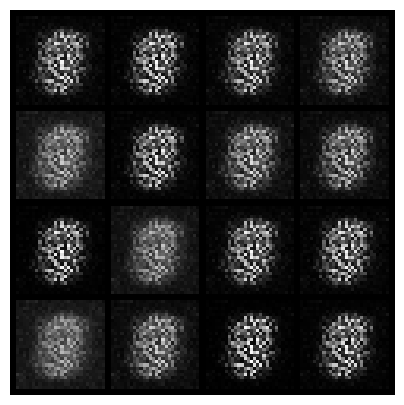

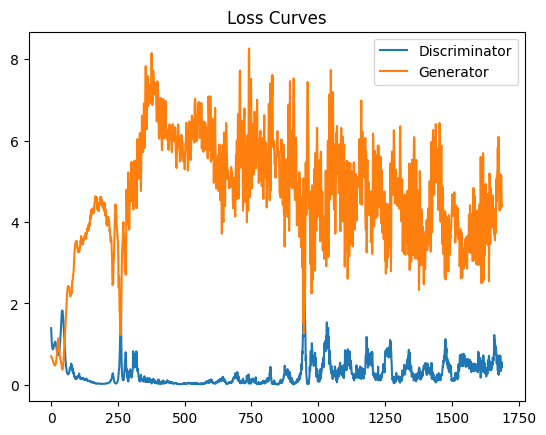

In [21]:
from torchvision import utils
import matplotlib.pyplot as plt
import numpy as np
import torch # Ensure torch is imported

# Evaluation
def show_samples():
    with torch.no_grad():
        noise = torch.randn(16, 100).to(device)
        samples = G(noise).cpu()
        grid = utils.make_grid(samples, nrow=4, normalize=True)
        plt.figure(figsize=(5,5))
        plt.imshow(np.transpose(grid, (1,2,0)))
        plt.axis('off')
        plt.show()

# After defining the function, you can call it
show_samples()

# Loss Plot
# Make sure these are also in a code cell to be executed
plt.plot(losses_D, label='Discriminator')
plt.plot(losses_G, label='Generator')
plt.legend()
plt.title('Loss Curves')
plt.show()

## Loss Plot
plt.plot(losses_D, label='Discriminator')
plt.plot(losses_G, label='Generator')
plt.legend()
plt.title('Loss Curves')
plt.show()